In [3]:
!pip install torchvision
!pip install --upgrade torchvision torch
!pip install timm

In [4]:
import os
import random
import cv2
import torch
import timm
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

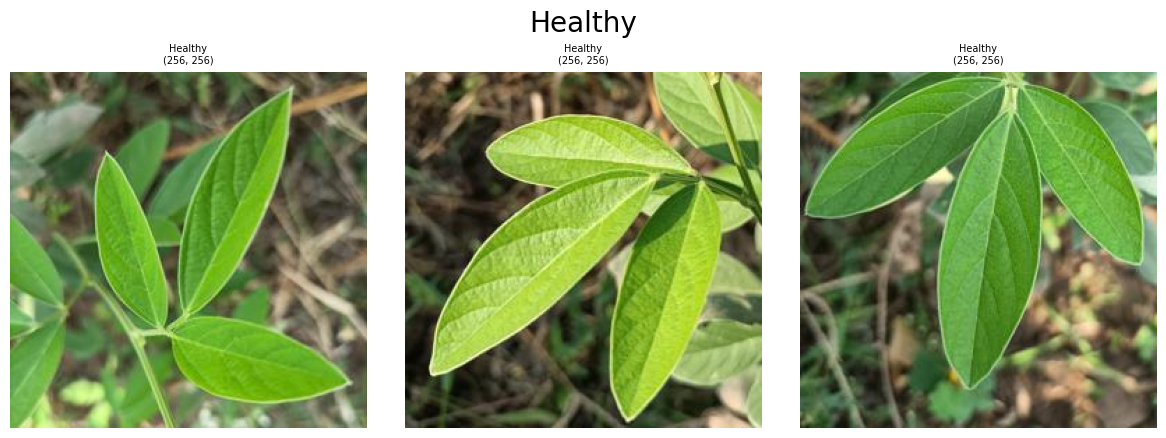

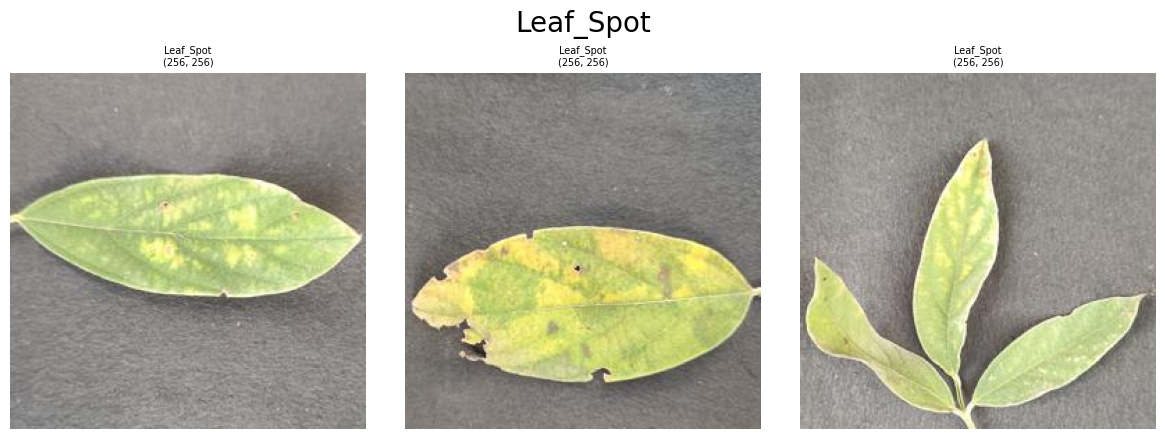

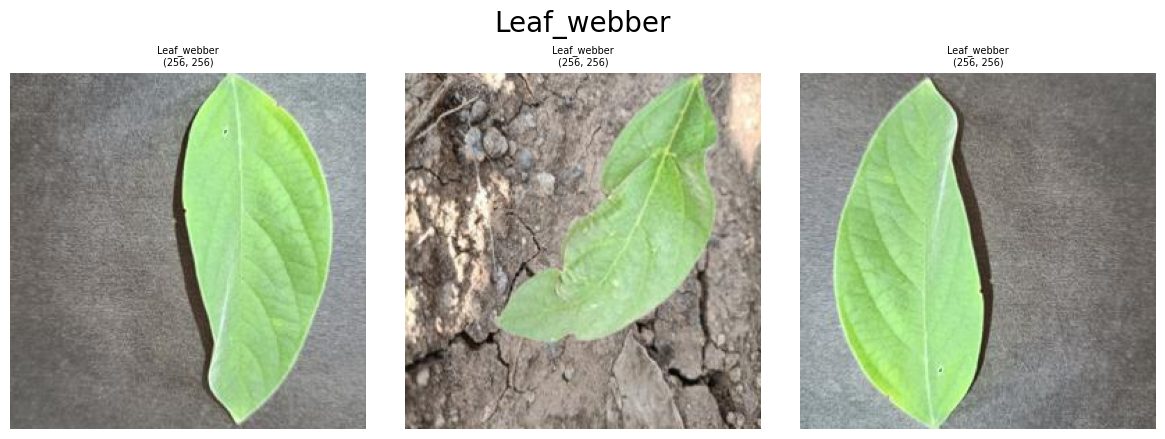

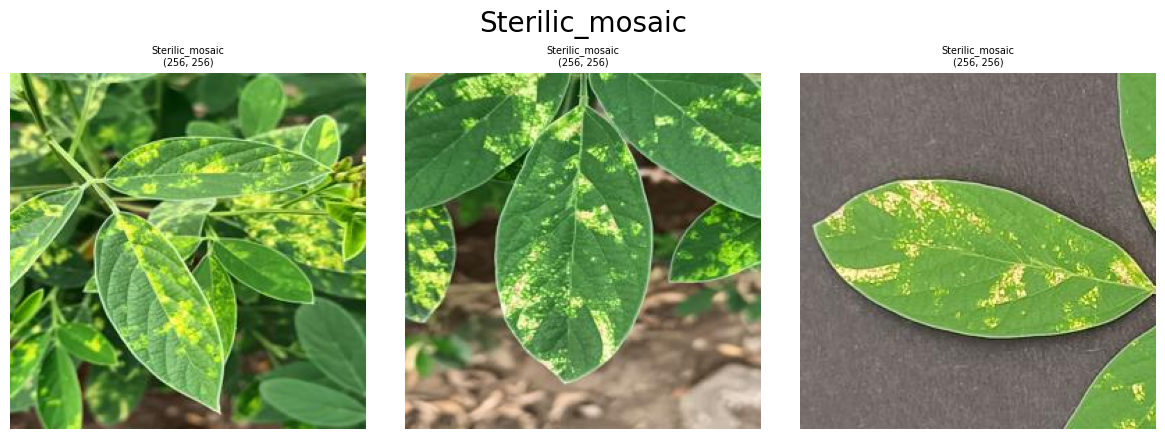

In [5]:
base_dir = "/Users/anushkaroy17/CBAM-ResGANet/PPLD"
classes = ["Healthy", "Leaf_Spot", "Leaf_webber", "Sterilic_mosaic"]

num_images = 3

for cls in classes:
    class_path = os.path.join(base_dir, cls)
    images = os.listdir(class_path)
    
    selected_images = random.sample(images, min(num_images, len(images)))
    
    plt.figure(figsize=(12, 12))
    plt.suptitle(cls, fontsize=20)
    
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(class_path, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        shape_text = img.shape[:2]           
        
    
        
        plt.subplot(3, 3, i+1) 
        plt.imshow(img)
        plt.title(f"{cls}\n{shape_text}", fontsize=7)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


In [6]:
data_dir = "/Users/anushkaroy17/CBAM-ResGANet/PPLD"

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(20),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])  # ResNet normalization
])

test_val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])
full_dataset = datasets.ImageFolder(root=f"{data_dir}", transform=train_transforms)

train_size = int(0.8 * len(full_dataset))
val_size = int(0.1 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

val_dataset.dataset.transform = test_val_transforms
test_dataset.dataset.transform = test_val_transforms

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Classes: {class_names}")
print(f"Number of classes: {num_classes}")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")


Classes: ['Healthy', 'Leaf_Spot', 'Leaf_webber', 'Sterilic_mosaic']
Number of classes: 4
Train: 778, Val: 97, Test: 98


In [7]:
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(device)

mps


Epoch 1/20 | Train Acc: 0.6093 | Val Acc: 0.7320 | Loss: 7.6095
Epoch 2/20 | Train Acc: 0.8136 | Val Acc: 0.7216 | Loss: 4.2033
Epoch 3/20 | Train Acc: 0.8393 | Val Acc: 0.7732 | Loss: 3.3415
Epoch 4/20 | Train Acc: 0.8419 | Val Acc: 0.7629 | Loss: 3.0132
Epoch 5/20 | Train Acc: 0.8715 | Val Acc: 0.7526 | Loss: 2.6255
Epoch 6/20 | Train Acc: 0.8689 | Val Acc: 0.7835 | Loss: 2.5687
Epoch 7/20 | Train Acc: 0.8702 | Val Acc: 0.7732 | Loss: 2.5553
Epoch 8/20 | Train Acc: 0.8895 | Val Acc: 0.8041 | Loss: 2.2280
Epoch 9/20 | Train Acc: 0.8805 | Val Acc: 0.7835 | Loss: 2.2267
Epoch 10/20 | Train Acc: 0.8779 | Val Acc: 0.7835 | Loss: 2.2025
Epoch 11/20 | Train Acc: 0.8997 | Val Acc: 0.7938 | Loss: 2.0182
Epoch 12/20 | Train Acc: 0.8933 | Val Acc: 0.7629 | Loss: 1.9621
Epoch 13/20 | Train Acc: 0.9075 | Val Acc: 0.7629 | Loss: 1.9137
Epoch 14/20 | Train Acc: 0.8959 | Val Acc: 0.7423 | Loss: 1.8546
Epoch 15/20 | Train Acc: 0.9049 | Val Acc: 0.7526 | Loss: 1.8999
Epoch 16/20 | Train Acc: 0.9049 | 

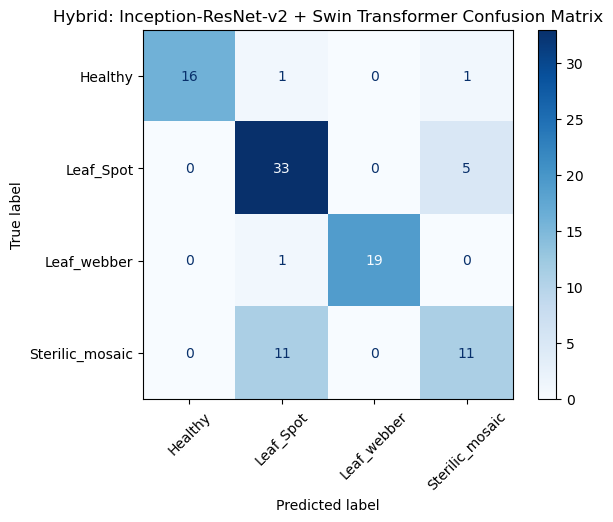

Classification Report:
                 precision    recall  f1-score   support

        Healthy       1.00      0.89      0.94        18
      Leaf_Spot       0.72      0.87      0.79        38
    Leaf_webber       1.00      0.95      0.97        20
Sterilic_mosaic       0.65      0.50      0.56        22

       accuracy                           0.81        98
      macro avg       0.84      0.80      0.82        98
   weighted avg       0.81      0.81      0.80        98



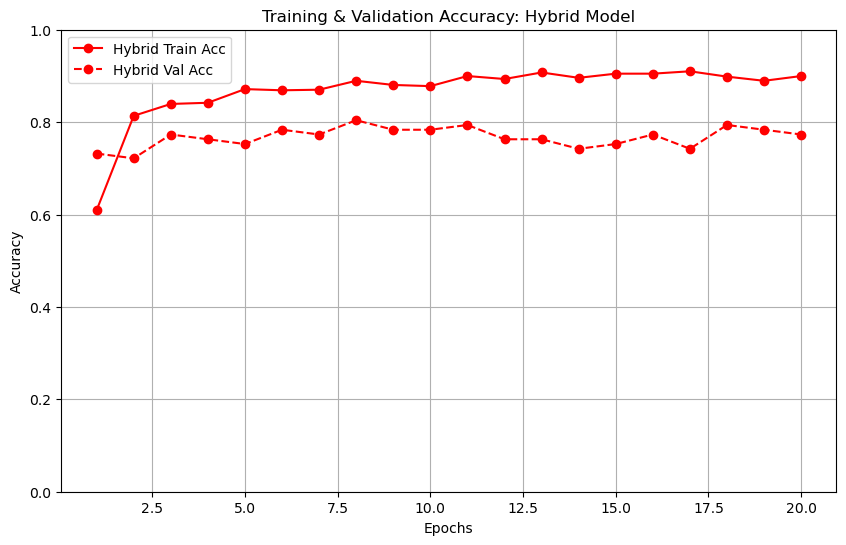

In [8]:




num_classes = len(class_names)

class HybridIRv2Swin(nn.Module):
    def __init__(self,
                 irv2_name='inception_resnet_v2',
                 swin_name='swin_tiny_patch4_window7_224',
                 pretrained=True,
                 freeze_backbones=True,
                 head_hidden=128,
                 dropout=0.3):
        super().__init__()


        self.ir = timm.create_model(irv2_name, pretrained=pretrained, num_classes=0, global_pool='avg')
        self.swin = timm.create_model(swin_name, pretrained=pretrained, num_classes=0, global_pool='avg')

        self.ir_features = getattr(self.ir, 'num_features', None)
        self.swin_features = getattr(self.swin, 'num_features', None)

        if self.ir_features is None or self.swin_features is None:
            raise ValueError("Could not auto-detect feature dims; check model names or timm version.")

        if freeze_backbones:
            for p in self.ir.parameters():
                p.requires_grad = False
            for p in self.swin.parameters():
                p.requires_grad = False

        concat_dim = self.ir_features + self.swin_features
        self.head = nn.Sequential(
            nn.Linear(concat_dim, head_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, num_classes)
        )

    def forward(self, x):
        feat_ir = self.ir(x)   # (B, ir_features)
        feat_swin = self.swin(x) # (B, swin_features)

        feat = torch.cat([feat_ir, feat_swin], dim=1)
        out = self.head(feat)
        return out
hybrid = HybridIRv2Swin(
    irv2_name='inception_resnet_v2',          
    swin_name='swin_tiny_patch4_window7_224',  
    pretrained=True,
    freeze_backbones=True,                     
    head_hidden=128,
    dropout=0.3
)

hybrid = hybrid.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, hybrid.parameters()), lr=1e-3)

def train_model(model, criterion, optimizer, train_loader, val_loader, num_epochs=20):
    history = {"train_acc": [], "val_acc": []}

    for epoch in range(num_epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_acc = correct / total if total > 0 else 0.0

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total if total > 0 else 0.0

        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Loss: {running_loss/total if total>0 else 0.0:.4f}")

    return history

# Train
history = train_model(hybrid, criterion, optimizer, train_loader, val_loader, num_epochs=20)

hybrid.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = hybrid(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Hybrid: Inception-ResNet-v2 + Swin Transformer Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

epochs = range(1, len(history["train_acc"]) + 1)
plt.figure(figsize=(10,6))
plt.plot(epochs, history["train_acc"], 'r-o', label='Hybrid Train Acc')
plt.plot(epochs, history["val_acc"], 'r--o', label='Hybrid Val Acc')
plt.title("Training & Validation Accuracy: Hybrid Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()


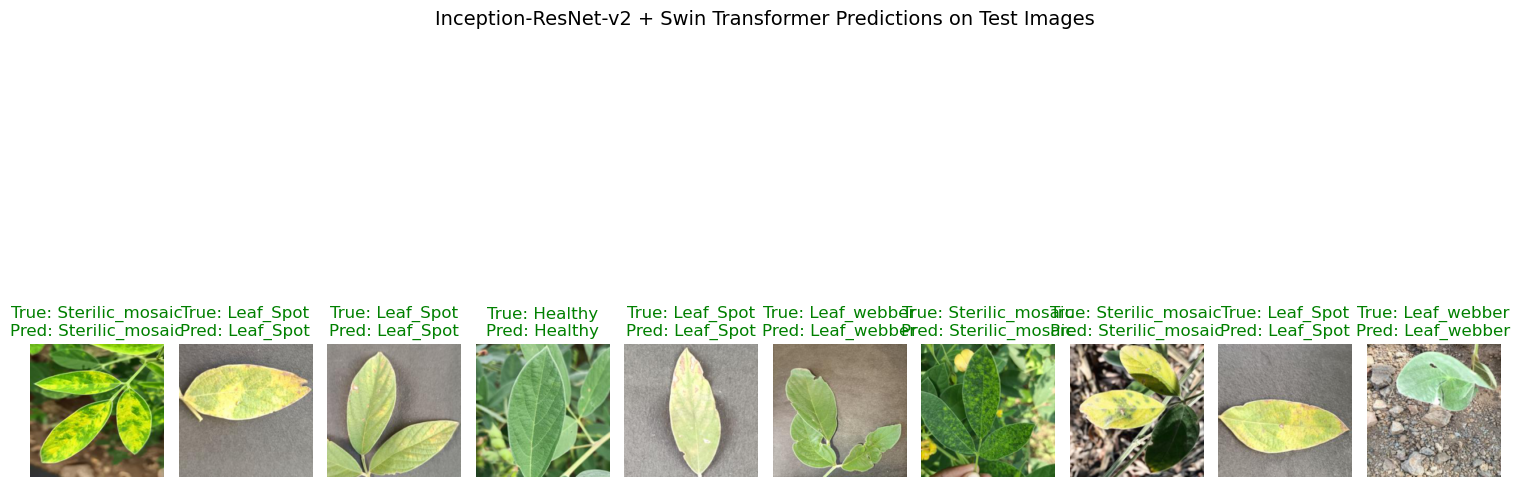

In [9]:
hybrid.eval()
indices = random.sample(range(len(test_dataset)), 10)
plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    img, label = test_dataset[idx]
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = hybrid(img_input)
        _, pred = torch.max(outputs, 1)

    true_label = class_names[label]
    predicted_label = class_names[pred.item()]
    img_display = img.cpu().permute(1, 2, 0).numpy()
    img_display = img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_display = np.clip(img_display, 0, 1)

    plt.subplot(1, 10, i + 1)
    plt.imshow(img_display)
    plt.title(f"True: {true_label}\nPred: {predicted_label}",
              color=("green" if true_label == predicted_label else "red"))
    plt.axis("off")
plt.suptitle("Inception-ResNet-v2 + Swin Transformer Predictions on Test Images", fontsize=14)
plt.tight_layout()
plt.show()


Epoch 1/20 | Train Acc: 0.3997 | Val Acc: 0.3711 | Train Loss: 1.2514
Epoch 2/20 | Train Acc: 0.6195 | Val Acc: 0.6804 | Train Loss: 1.0066
Epoch 3/20 | Train Acc: 0.7172 | Val Acc: 0.6804 | Train Loss: 0.8168
Epoch 4/20 | Train Acc: 0.7828 | Val Acc: 0.7113 | Train Loss: 0.6920
Epoch 5/20 | Train Acc: 0.7982 | Val Acc: 0.7526 | Train Loss: 0.6035
Epoch 6/20 | Train Acc: 0.8059 | Val Acc: 0.7732 | Train Loss: 0.5587
Epoch 7/20 | Train Acc: 0.8213 | Val Acc: 0.7423 | Train Loss: 0.5032
Epoch 8/20 | Train Acc: 0.8123 | Val Acc: 0.8144 | Train Loss: 0.5036
Epoch 9/20 | Train Acc: 0.8059 | Val Acc: 0.8041 | Train Loss: 0.4915
Epoch 10/20 | Train Acc: 0.8355 | Val Acc: 0.7629 | Train Loss: 0.4555
Epoch 11/20 | Train Acc: 0.8419 | Val Acc: 0.7835 | Train Loss: 0.4330
Epoch 12/20 | Train Acc: 0.8213 | Val Acc: 0.7629 | Train Loss: 0.4298
Epoch 13/20 | Train Acc: 0.8458 | Val Acc: 0.7835 | Train Loss: 0.4139
Epoch 14/20 | Train Acc: 0.8342 | Val Acc: 0.7835 | Train Loss: 0.4166
Epoch 15/20 | T

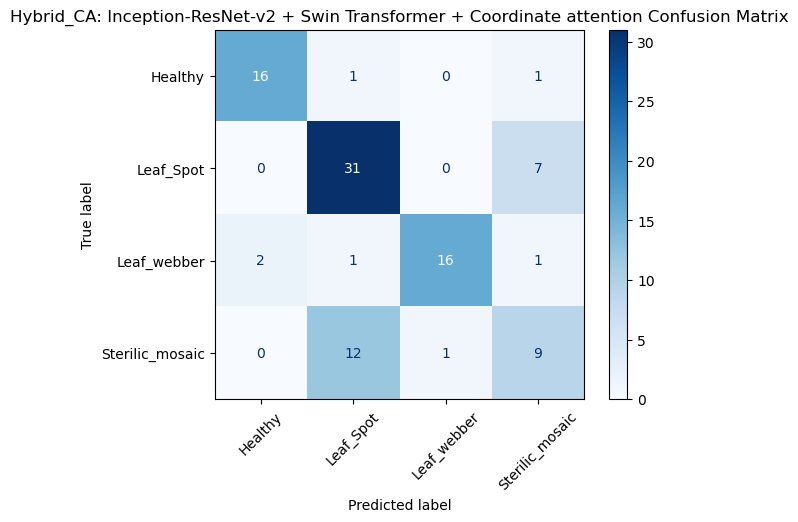

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.89      0.89      0.89        18
      Leaf_Spot       0.69      0.82      0.75        38
    Leaf_webber       0.94      0.80      0.86        20
Sterilic_mosaic       0.50      0.41      0.45        22

       accuracy                           0.73        98
      macro avg       0.75      0.73      0.74        98
   weighted avg       0.73      0.73      0.73        98



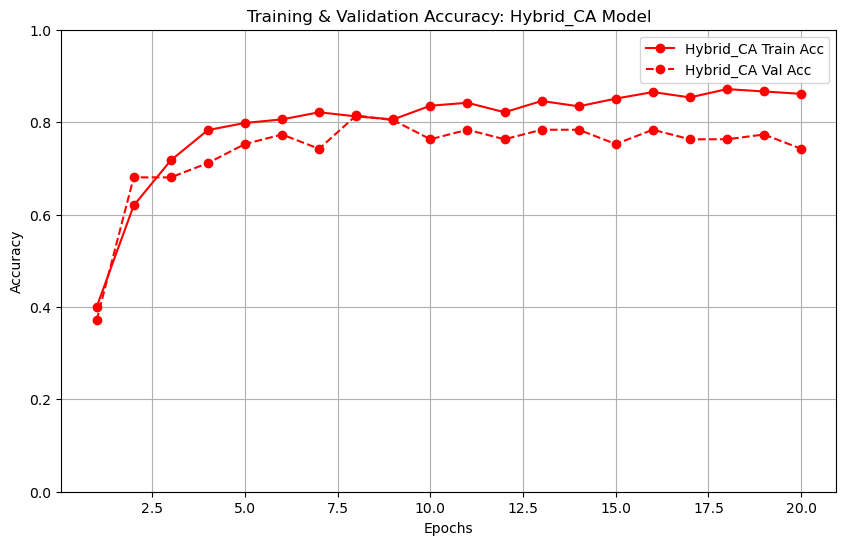

In [10]:

class CoordAtt(nn.Module):
    def __init__(self, inp, oup, reduction=32):
        super().__init__()
        self.pool_h = nn.AdaptiveAvgPool2d((None, 1))
        self.pool_w = nn.AdaptiveAvgPool2d((1, None))
        mid = max(8, inp // reduction)
        self.conv1 = nn.Conv2d(inp, mid, kernel_size=1, stride=1, padding=0)
        self.bn1 = nn.BatchNorm2d(mid)
        self.act = nn.ReLU(inplace=True)
        self.conv_h = nn.Conv2d(mid, oup, kernel_size=1, stride=1, padding=0)
        self.conv_w = nn.Conv2d(mid, oup, kernel_size=1, stride=1, padding=0)

    def forward(self, x):
        b, c, h, w = x.size()
        x_h = x.mean(dim=3, keepdim=True)
        x_w = x.mean(dim=2, keepdim=True).permute(0, 1, 3, 2)
        y = torch.cat([x_h, x_w], dim=2)
        y = self.conv1(y)
        y = self.bn1(y)
        y = self.act(y)
        x_h, x_w = torch.split(y, [h, w], dim=2)
        x_w = x_w.permute(0, 1, 3, 2)
        a_h = self.conv_h(x_h).sigmoid()
        a_w = self.conv_w(x_w).sigmoid()
        out = x * a_h * a_w
        return out

class BackboneWithCoord(nn.Module):
    def __init__(self, model_name, pretrained=True, apply_coord=True):
        super().__init__()
        self.model = timm.create_model(model_name, pretrained=pretrained, num_classes=0, global_pool='')
        self.apply_coord = apply_coord
        dummy = torch.randn(1, 3, 224, 224)
        self.model.eval()
        with torch.no_grad():
            try:
                fmap = self.model.forward_features(dummy)
            except Exception:
                fmap = self.model(dummy)
        if isinstance(fmap, torch.Tensor) and fmap.dim() == 4:
            feat_c = fmap.shape[1]
        else:
            feat_c = getattr(self.model, 'num_features', None) or 0
        self.coord = CoordAtt(feat_c, feat_c) if (self.apply_coord and feat_c>0) else None
        self.pool = nn.AdaptiveAvgPool2d((1,1))

    def forward(self, x):
        if hasattr(self.model, 'forward_features'):
            fmap = self.model.forward_features(x)
        else:
            out = self.model(x)
            if out.dim() == 4:
                fmap = out
            else:
                return out
        if fmap.dim() == 4:
            if self.coord is not None:
                fmap = self.coord(fmap)
            vec = self.pool(fmap).flatten(1)
            return vec
        else:
            return fmap

class HybridIRv2SwinCA(nn.Module):
    def __init__(self,
                 irv2_name='inception_resnet_v2',
                 swin_name='swin_tiny_patch4_window7_224',
                 pretrained=True,
                 freeze_backbones=True,
                 head_hidden=128,
                 dropout=0.3):
        super().__init__()
        self.ir_backbone = BackboneWithCoord(irv2_name, pretrained=pretrained, apply_coord=True)
        self.swin_backbone = BackboneWithCoord(swin_name, pretrained=pretrained, apply_coord=True)
        self.ir_features = 0
        self.swin_features = 0
        sample = torch.randn(1,3,224,224)
        with torch.no_grad():
            v1 = self.ir_backbone(sample)
            v2 = self.swin_backbone(sample)
        self.ir_features = v1.shape[1] if isinstance(v1, torch.Tensor) else 0
        self.swin_features = v2.shape[1] if isinstance(v2, torch.Tensor) else 0
        if self.ir_features == 0 or self.swin_features == 0:
            raise ValueError("Could not determine feature dims; check model names.")
        if freeze_backbones:
            for p in self.ir_backbone.parameters():
                p.requires_grad = False
            for p in self.swin_backbone.parameters():
                p.requires_grad = False
        concat_dim = self.ir_features + self.swin_features
        self.head = nn.Sequential(
            nn.Linear(concat_dim, head_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, num_classes)
        )

    def forward(self, x):
        feat_ir = self.ir_backbone(x)
        feat_swin = self.swin_backbone(x)
        feat = torch.cat([feat_ir, feat_swin], dim=1)
        out = self.head(feat)
        return out

hybrid_ca = HybridIRv2SwinCA(
    irv2_name='inception_resnet_v2',
    swin_name='swin_tiny_patch4_window7_224',
    pretrained=True,
    freeze_backbones=True,
    head_hidden=128,
    dropout=0.3
)

hybrid_ca = hybrid_ca.to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, hybrid_ca.parameters()), lr=1e-3)

def train_model_ca(model, criterion, optimizer, train_loader, val_loader, num_epochs=20):
    history_ca = {"train_acc": [], "val_acc": []}
    for epoch in range(num_epochs):
        model.train()
        correct, total, running_loss = 0, 0, 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        train_acc = correct / total if total > 0 else 0.0
        avg_train_loss = running_loss / total if total > 0 else 0.0
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)
        val_acc = correct / total if total > 0 else 0.0
        history_ca["train_acc"].append(train_acc)
        history_ca["val_acc"].append(val_acc)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Train Loss: {avg_train_loss:.4f}")
    return history_ca

history_ca = train_model_ca(hybrid_ca, criterion, optimizer, train_loader, val_loader, num_epochs=20)

hybrid_ca.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = hybrid_ca(imgs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Hybrid_CA: Inception-ResNet-v2 + Swin Transformer + Coordinate attention Confusion Matrix")
plt.show()

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))

epochs = range(1, len(history_ca["train_acc"]) + 1)
plt.figure(figsize=(10,6))
plt.plot(epochs, history_ca["train_acc"], 'r-o', label='Hybrid_CA Train Acc')
plt.plot(epochs, history_ca["val_acc"], 'r--o', label='Hybrid_CA Val Acc')
plt.title("Training & Validation Accuracy: Hybrid_CA Model")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()


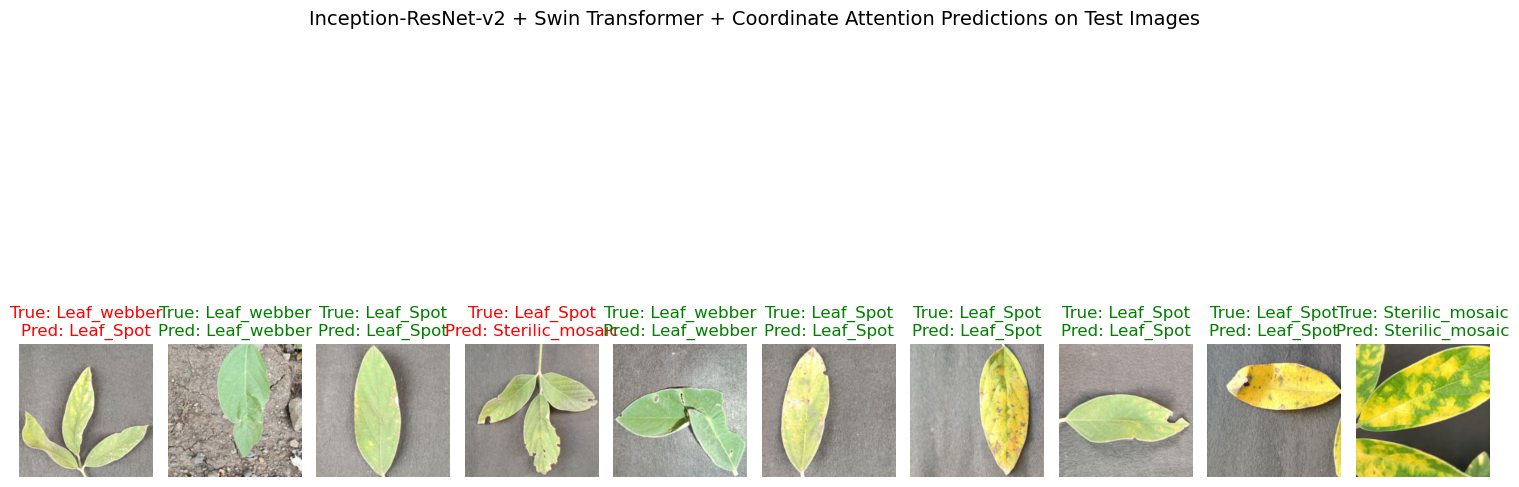

In [11]:
hybrid_ca.eval()
indices = random.sample(range(len(test_dataset)), 10)
plt.figure(figsize=(15, 8))
for i, idx in enumerate(indices):
    img, label = test_dataset[idx]
    img_input = img.unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = hybrid_ca(img_input)
        _, pred = torch.max(outputs, 1)

    true_label = class_names[label]
    predicted_label = class_names[pred.item()]
    img_display = img.cpu().permute(1, 2, 0).numpy()
    img_display = img_display * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img_display = np.clip(img_display, 0, 1)

    plt.subplot(1, 10, i + 1)
    plt.imshow(img_display)
    plt.title(f"True: {true_label}\nPred: {predicted_label}",
              color=("green" if true_label == predicted_label else "red"))
    plt.axis("off")
plt.suptitle("Inception-ResNet-v2 + Swin Transformer + Coordinate Attention Predictions on Test Images", fontsize=14)
plt.tight_layout()
plt.show()


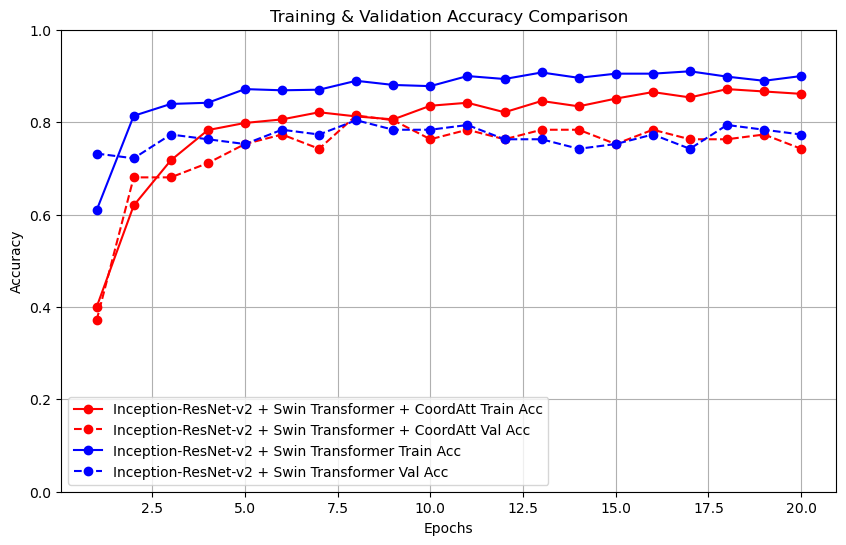

In [12]:
stf_val_acc = history['val_acc']
stf_train_acc = history['train_acc']


stf_cbam_val_acc = history_ca['val_acc']
stf_cbam_train_acc = history_ca['train_acc']

epochs = range(1, len(stf_val_acc) + 1)

plt.figure(figsize=(10,6))

plt.plot(epochs, stf_cbam_train_acc, 'r-o', label='Inception-ResNet-v2 + Swin Transformer + CoordAtt Train Acc')
plt.plot(epochs, stf_cbam_val_acc, 'r--o', label='Inception-ResNet-v2 + Swin Transformer + CoordAtt Val Acc')

plt.plot(epochs, stf_train_acc, 'b-o', label='Inception-ResNet-v2 + Swin Transformer Train Acc')
plt.plot(epochs, stf_val_acc, 'b--o', label='Inception-ResNet-v2 + Swin Transformer Val Acc')

plt.title("Training & Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.show()
